In [17]:
# Section 1: Imports and Environment Setup
import cv2
import numpy as np
import csv
import os
import time
import torch
import matplotlib.pyplot as plt
import warnings

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.models import vgg16
from torchmetrics.image.fid import FrechetInceptionDistance
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision import transforms

from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm
from skimage.color import lab2rgb

warnings.filterwarnings("ignore", message="Failed to initialize NumPy: _ARRAY_API not found")


In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
##############   TEST CELL ##########################################
import torch
checkpoint_path = '/home/mmanani/ImageColourizationDataSet/checkpoints/gan_checkpoint.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cuda'))  # Load on CPU first
    print("Checkpoint loaded successfully!")
    print("Epoch:", checkpoint['epoch'])
    print("Loss:", checkpoint['loss'])
else:
    print("Checkpoint not found!")
##############   TEST CELL ##########################################

Checkpoint loaded successfully!
Epoch: 271
Loss: {'G': 25.982452392578125, 'D': 0.5032044649124146}


In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [5]:
import os

# Base directory
base_dir = r'/home/mmanani/ImageColourizationDataSet/ILSVRC/Data/DET/train'

# Get all subdirectories
sub_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

# Count images in each subdirectory
for folder in sub_dirs:
    folder_path = os.path.join(base_dir, folder)
    image_count = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    print(f"{folder}: {image_count} images")

# Total count
total_images = sum(len([f for f in os.listdir(os.path.join(base_dir, d)) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]) 
                  for d in sub_dirs if os.path.isdir(os.path.join(base_dir, d)))
print(f"Total images: {total_images}")

ILSVRC2013_train_extra2: 9939 images
ILSVRC2013_train_extra8: 10000 images
ILSVRC2013_train_extra4: 9990 images
ILSVRC2013_train_extra10: 7505 images
ILSVRC2014_train_0001: 10000 images
ILSVRC2014_train_0002: 10000 images
ILSVRC2013_train: 0 images
ILSVRC2014_train_0000: 9999 images
ILSVRC2013_train_extra3: 9946 images
ILSVRC2013_train_extra1: 9948 images
ILSVRC2013_train_extra7: 10000 images
ILSVRC2013_train_extra9: 9999 images
ILSVRC2014_train_0004: 10000 images
ILSVRC2014_train_0005: 10000 images
ILSVRC2014_train_0003: 10000 images
ILSVRC2013_train_extra5: 9997 images
ILSVRC2013_train_extra6: 9996 images
ILSVRC2013_train_extra0: 9928 images
ILSVRC2014_train_0006: 659 images
Total images: 167906


In [15]:
# Hyperparameters
batch_size = 16              # ✅ Keep — good balance for stability vs GPU memory
pretrain_epochs = 15         # ⬆️ From 10 → 15 (lets generator learn color mapping better before adversarial training)
num_epochs = 300             # ⬆️ Slightly higher to allow slower GAN convergence
learning_rate_g = 1.2e-4     # ⬆️ From 1e-4 → 2e-4 (G learns slightly faster during pretraining & GAN phase)
learning_rate_d = 6e-5       # ⬇️ From 3e-4 → 1e-4 (slows D to prevent early dominance)
beta1, beta2 = 0.5, 0.999    # Adam betas — good default for GAN stability
lambda_L1 = 60              # Weight for L1 loss (keep)
lambda_perceptual = 1.0      # Weight for perceptual loss (tune if too smooth or too noisy)
lambda_gan = 1.2             # new — scale GAN loss a bit lower to prevent hallucinated hues

In [7]:
# Section 2: Improved Dataset Class for U-Net GAN
from torch.utils.data import Dataset
import torch
import os
import cv2
import numpy as np
import random
from torchvision import transforms

class ColorizationDataset(Dataset):
    def __init__(self, image_dir,transform_prob=0.5, max_size=7*1024*1024*1024):
        """
        image_dir: Root folder containing training images
        transform_prob: Probability for applying augmentations
        max_size: Cap dataset size (default: 5 GB)
        """
        self.image_paths = []
        total_size = 0

        # Walk directory and collect images up to max_size
        for root, _, files in os.walk(image_dir):
            random.shuffle(files)  # Helps distribute diversity
            for file in files:
                if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                    path = os.path.join(root, file)
                    try:
                        size = os.path.getsize(path)
                    except OSError:
                        continue
                    if total_size + size <= max_size:
                        self.image_paths.append(path)
                        total_size += size
                    else:
                        break
            if total_size >= max_size:
                break

        if not self.image_paths:
            raise ValueError(f"No valid images found in {image_dir}.")
        self.transform_prob = transform_prob
        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        try:
            img = cv2.imread(img_path)
            if img is None:
                raise ValueError
        except Exception:
            # fallback to another random image
            return self.__getitem__(random.randint(0, len(self.image_paths)-1))

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (256, 256), interpolation=cv2.INTER_AREA)

        # Occasionally apply augmentations
        if random.random() < self.transform_prob:
            img_rgb = np.array(self.augment(transforms.ToPILImage()(img_rgb)))

        # Convert to LAB
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

        # Normalize L to [-1, 1] and ab to [-1, 1]
        l_channel = (img_lab[:, :, 0] / 50.0) - 1.0        # L in [-1, 1]
        ab_channels = (img_lab[:, :, 1:] - 128) / 128.0    # ab in [-1, 1]

        # Convert to tensors
        l_channel = torch.from_numpy(l_channel).float().unsqueeze(0)
        ab_channels = torch.from_numpy(ab_channels.transpose((2, 0, 1))).float()

        return {'L': l_channel, 'ab': ab_channels}

In [8]:
# Path to dataset
image_dir = r'/home/mmanani/ImageColourizationDataSet/ILSVRC/Data/DET/train'
# Load dataset with correct transform
dataset = ColorizationDataset(image_dir)
# Split into train/val/test
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


In [9]:
# Section 3: Model Definition
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, input_channels=1, output_channels=2, feature_maps=64):
        super(Generator, self).__init__()

        # Encoder (Downsampling path)
        self.enc1 = self._block(input_channels, feature_maps, normalize=False)  # 1 → 64
        self.enc2 = self._block(feature_maps, feature_maps * 2)
        self.enc3 = self._block(feature_maps * 2, feature_maps * 4)
        self.enc4 = self._block(feature_maps * 4, feature_maps * 8)
        self.enc5 = self._block(feature_maps * 8, feature_maps * 8)
        self.enc6 = self._block(feature_maps * 8, feature_maps * 8)
        self.enc7 = self._block(feature_maps * 8, feature_maps * 8)
        self.enc8 = self._block(feature_maps * 8, feature_maps * 8, normalize=False)

        # Decoder (Upsampling path with skip connections)
        self.dec1 = self._up_block(feature_maps * 8, feature_maps * 8, dropout=True)
        self.dec2 = self._up_block(feature_maps * 16, feature_maps * 8, dropout=True)
        self.dec3 = self._up_block(feature_maps * 16, feature_maps * 8, dropout=True)
        self.dec4 = self._up_block(feature_maps * 16, feature_maps * 8)
        self.dec5 = self._up_block(feature_maps * 16, feature_maps * 4)
        self.dec6 = self._up_block(feature_maps * 8, feature_maps * 2)
        self.dec7 = self._up_block(feature_maps * 4, feature_maps)
        self.dec8 = nn.Sequential(
            nn.ConvTranspose2d(feature_maps * 2, output_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def _block(self, in_channels, out_channels, normalize=True):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def _up_block(self, in_channels, out_channels, dropout=False):
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)
        e6 = self.enc6(e5)
        e7 = self.enc7(e6)
        e8 = self.enc8(e7)

        # Decoder with skip connections
        d1 = self.dec1(e8);  d1 = torch.cat([d1, e7], 1)
        d2 = self.dec2(d1);  d2 = torch.cat([d2, e6], 1)
        d3 = self.dec3(d2);  d3 = torch.cat([d3, e5], 1)
        d4 = self.dec4(d3);  d4 = torch.cat([d4, e4], 1)
        d5 = self.dec5(d4);  d5 = torch.cat([d5, e3], 1)
        d6 = self.dec6(d5);  d6 = torch.cat([d6, e2], 1)
        d7 = self.dec7(d6);  d7 = torch.cat([d7, e1], 1)
        d8 = self.dec8(d7)
        return d8


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # Input: (3, 256, 256)
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),            # (64, 128, 128)
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),          # (128, 64, 64)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),         # (256, 32, 32)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 1, 1),         # (512, 31, 31)
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 1),           # (1, 30, 30)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [10]:
# Initialize models
# Initialize models
G = Generator().to(device)
D = Discriminator().to(device)

# Apply weight initialization
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

G.apply(weights_init_normal)
D.apply(weights_init_normal)

# Load pretrained VGG for perceptual loss
from torchvision.models import vgg16, VGG16_Weights
vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features[:16].eval().to(device)
for param in vgg.parameters():
    param.requires_grad = False

vgg_mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
vgg_std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

def perceptual_loss(pred, target):
    pred_norm = (pred - vgg_mean) / vgg_std
    target_norm = (target - vgg_mean) / vgg_std
    pred_features = vgg(pred_norm)
    target_features = vgg(target_norm)
    return nn.functional.mse_loss(pred_features, target_features)

# Loss functions
criterion_GAN = nn.BCELoss().to(device)
criterion_L1 = nn.L1Loss().to(device)

# Optimizers
optimizer_G = torch.optim.Adam(G.parameters(), lr=learning_rate_g, betas=(beta1, beta2))
optimizer_D = torch.optim.Adam(D.parameters(), lr=learning_rate_d, betas=(beta1, beta2))

In [12]:
# Section 5: Training Loop
# Assuming these are defined earlier: device, pretrain_epochs, num_epochs, train_loader, G, D, optimizer_G, optimizer_D, criterion_L1, perceptual_loss
# train_step definition with error fix
def train_step(G, D, optimizer_G, optimizer_D, real_ab, L):
    # Generator
    fake_ab = G(L)
    fake_img = torch.cat([L, fake_ab], dim=1)
    # Discriminator (real)
    real_img = torch.cat([L, real_ab], dim=1)
    real_pred = D(real_img)
    real_label = torch.clamp(1.0 - torch.rand_like(real_pred) * 0.1, 0.9, 1.0)
    # Discriminator (fake)
    fake_pred = D(fake_img.detach())
    fake_label = torch.clamp(torch.rand_like(fake_pred) * 0.1, 0.0, 0.1)
    # D loss
    d_loss_real = criterion_GAN(real_pred, real_label)
    d_loss_fake = criterion_GAN(fake_pred, fake_label)
    d_loss = (d_loss_real + d_loss_fake) / 2
    optimizer_D.zero_grad()
    d_loss.backward()
    optimizer_D.step()
    # G loss
    fake_pred = D(fake_img)
    g_gan_loss = criterion_GAN(fake_pred, real_label)
    g_l1_loss = criterion_L1(fake_ab, real_ab) * 100
    g_perceptual_loss = perceptual_loss(fake_img, real_img)
    g_loss = g_gan_loss + g_l1_loss + g_perceptual_loss
    optimizer_G.zero_grad()
    g_loss.backward()
    optimizer_G.step()
    return g_loss.item(), d_loss.item()
checkpoint_dir = '/home/mmanani/ImageColourizationDataSet/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Function to load checkpoint (updated for GAN to load both G and D)
def load_checkpoint(checkpoint_path, models, optimizers):
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location='cpu')

        # Detect format automatically
        if isinstance(checkpoint['model_state_dict'], dict) and 'G' in checkpoint['model_state_dict']:
            # Multi-model (GAN) checkpoint
            for key in models:
                models[key].load_state_dict(checkpoint['model_state_dict'][key])
            for key in optimizers:
                optimizers[key].load_state_dict(checkpoint['optimizer_state_dict'][key])
        else:
            # Single-model (Pretraining) checkpoint
            list(models.values())[0].load_state_dict(checkpoint['model_state_dict'])
            list(optimizers.values())[0].load_state_dict(checkpoint['optimizer_state_dict'])

        start_epoch = checkpoint.get('epoch', 0)
        start_batch = checkpoint.get('batch', 0)
        loss = checkpoint.get('loss', None)
        print(f"✅ Resumed from checkpoint at epoch {start_epoch}, batch {start_batch}, loss {loss}")
        return start_epoch, start_batch

    print("⚠️ No checkpoint found, starting fresh.")
    return 0, 0


# -----------------------------
# 2. PER-EPOCH COPY (MAIN CHECKPOINT UNCHANGED)
# -----------------------------
def save_per_epoch_copy(epoch, checkpoint_dir="checkpoints"):
    main_path = os.path.join(checkpoint_dir, 'gan_checkpoint.pth')
    if not os.path.exists(main_path):
        return
    copy_path = os.path.join(checkpoint_dir, f'gan_checkpoint_epoch_{epoch+1}.pth')
    import shutil
    shutil.copy2(main_path, copy_path)
    print(f"Epoch copy saved: {copy_path}")


In [12]:
# ==========================================
# Pretraining Generator (L1 + Perceptual)
# ==========================================
print("Pretraining Generator...")
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(log_dir='runs/colorization_gan')

# Load checkpoint if exists
start_epoch, start_batch = load_checkpoint(
    os.path.join(checkpoint_dir, 'pretrain_checkpoint.pth'),     
    {"G": G},
    {"optimizer_G": optimizer_G}
)

for epoch in range(start_epoch, pretrain_epochs):
    G.train()
    total_g_loss = 0.0
    start_time = time.time()

    # Handle resumption from a specific batch
    if epoch == start_epoch and start_batch > 0:
        print(f"⏩ Resuming from batch {start_batch} of epoch {start_epoch}")
        iterator = iter(train_loader)
        for _ in range(start_batch):
            next(iterator)
        batches = iterator
    else:
        batches = iter(train_loader)

    for batch_idx, batch in enumerate(
        tqdm(batches, desc=f"Pretrain Epoch {epoch+1}/{pretrain_epochs}", total=len(train_loader))
    ):
        # Skip batches before resumption point
        if epoch == start_epoch and batch_idx < start_batch:
            continue

        L = batch['L'].to(device)
        real_ab = batch['ab'].to(device)

        # Forward pass
        fake_ab = G(L)

        # Compute losses
        g_l1_loss = criterion_L1(fake_ab, real_ab) * lambda_L1
        g_perceptual_loss = perceptual_loss(
            torch.cat([L, fake_ab], dim=1),
            torch.cat([L, real_ab], dim=1)
        ) * lambda_perceptual
        g_loss = g_l1_loss + g_perceptual_loss

        # Backpropagation
        optimizer_G.zero_grad(set_to_none=True)
        g_loss.backward()
        optimizer_G.step()

        total_g_loss += g_loss.item()

        global_step = epoch * len(train_loader) + batch_idx
        writer.add_scalar('Pretrain/L1_Loss', g_l1_loss.item(), global_step)
        writer.add_scalar('Pretrain/Perceptual_Loss', g_perceptual_loss.item(), global_step)
        writer.add_scalar('Pretrain/Total_G_Loss', g_loss.item(), global_step)


        # Auto checkpoint every N batches
        if (batch_idx + 1) % 500 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, 'pretrain_checkpoint.pth')
            torch.save({
                'epoch': epoch,
                'batch': batch_idx + 1,
                'model_state_dict': G.state_dict(),
                'optimizer_state_dict': optimizer_G.state_dict(),
                'loss': g_loss.item()
            }, checkpoint_path)
            print(f"💾 Saved intermediate checkpoint at batch {batch_idx + 1}")
    # End of epoch logging
    avg_g_loss = total_g_loss / len(train_loader)
    print(f"✅ Pretrain Epoch [{epoch+1}/{pretrain_epochs}] | Avg G Loss: {avg_g_loss:.4f}")

    # Save epoch checkpoint
    torch.save({
        'epoch': epoch + 1,
        'batch': 0,
        'model_state_dict': G.state_dict(),
        'optimizer_state_dict': optimizer_G.state_dict(),
        'loss': avg_g_loss
    }, os.path.join(checkpoint_dir, 'pretrain_checkpoint.pth'))
writer.close()
print("🎯 Generator pretraining complete!")

Pretraining Generator...


2025-11-03 18:42:10.417317: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Resumed from checkpoint at epoch 15, batch 0, loss 121.94763626438557
🎯 Generator pretraining complete!


In [20]:
# =========================================================
#  Section 6: Inference and Visualization (Final Version)
# =========================================================
import torch
import numpy as np
import cv2
from skimage.color import lab2rgb

# -----------------------------
# Colorization Inference Function
# -----------------------------
def colorize_image(image_path, G, device='cuda'):
    """
    Takes a grayscale image path and returns a colorized RGB image.
    """
    G.eval()

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"❌ Failed to load image: {image_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Convert to LAB (float32)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    l_channel = lab[:, :, 0]

    # --- Match training normalization ---
    l_resized = cv2.resize(l_channel, (256, 256), interpolation=cv2.INTER_AREA).astype(np.float32)
    if l_resized.max() > 100.0:              # normalize to 0–100 if image is 0–255
        l_resized = (l_resized / 255.0) * 100.0
    l_input = torch.from_numpy((l_resized / 50.0 - 1.0)).unsqueeze(0).unsqueeze(0).to(device)

    # --- Generator prediction ---
    with torch.no_grad():
        ab_pred = G(l_input)
        ab_pred = torch.clamp(ab_pred, -1.0, 1.0)
        ab_pred = ab_pred.squeeze(0).cpu().numpy() * 128.0  # Denormalize to [-128, 127]

    # --- Resize and combine ---
    ab_resized = cv2.resize(ab_pred.transpose(1, 2, 0), (w, h), interpolation=cv2.INTER_CUBIC)
    np.clip(ab_resized, -128, 127, out=ab_resized)

    l_original = cv2.resize(l_channel, (w, h), interpolation=cv2.INTER_AREA).astype(np.float32)
    if l_original.max() > 100.0:
        l_original = (l_original / 255.0) * 100.0

    lab_full = np.dstack((l_original, ab_resized)).astype(np.float64)
    rgb = lab2rgb(lab_full)
    rgb = np.clip(rgb * 255, 0, 255).astype(np.uint8)
    return rgb


# =========================================================
#  Smoothness Loss Function (Minor Stability Tweak)
# =========================================================
def smoothness_loss(ab):
    """
    Encourages smooth spatial variation in the ab color channels.
    """
    dx = torch.abs(ab[:, :, :, 1:] - ab[:, :, :, :-1])
    dy = torch.abs(ab[:, :, 1:, :] - ab[:, :, :-1, :])
    loss = (dx.mean() + dy.mean()) * 0.1  # tuned to 0.1 for mild smoothing
    return loss

# =========================================================
#  Differentiable LAB → RGB (GPU-optimized)
# =========================================================
def lab_to_rgb_torch(L, ab):
    """Convert LAB ([-1,1]) tensors to RGB [0,1] on GPU (differentiable)."""
    L = (L + 1) * 50.0
    a = ab[:, 0:1] * 128.0
    b = ab[:, 1:2] * 128.0
    lab = torch.cat([L, a, b], dim=1).permute(0, 2, 3, 1)

    eps, kappa = 0.008856, 903.3
    fY = (lab[..., 0] + 16.0) / 116.0
    fX = fY + (lab[..., 1] / 500.0)
    fZ = fY - (lab[..., 2] / 200.0)

    f3 = lambda f: torch.where(f**3 > eps, f**3, (116 * f - 16) / kappa)
    Xn, Yn, Zn = 0.95047, 1.0, 1.08883
    X, Y, Z = f3(fX) * Xn, f3(fY) * Yn, f3(fZ) * Zn
    xyz = torch.stack([X, Y, Z], dim=-1)

    M = torch.tensor([[3.2406, -1.5372, -0.4986],
                      [-0.9689, 1.8758, 0.0415],
                      [0.0557, -0.2040, 1.0570]],
                      device=lab.device, dtype=lab.dtype)
    rgb = torch.matmul(xyz.view(-1, 3), M.T).view_as(xyz)
    rgb = torch.clamp(rgb, 0.0, None)

    threshold, a = 0.0031308, 0.055
    c_pow = rgb.clamp(min=0.0).pow(1.0 / 2.4)
    rgb = torch.where(rgb > threshold, 1.055 * c_pow - 0.055, 12.92 * rgb)
    rgb = rgb.permute(0, 3, 1, 2).clamp(0, 1)
    return rgb.contiguous()


In [25]:
# =========================================================
#  GAN Training (Improved for Stability + Color Regularization)
# =========================================================
from torch.utils.tensorboard import SummaryWriter
fid_metric = FrechetInceptionDistance(feature=64).to(device)
tbwriter = SummaryWriter(log_dir='runs/colorization_gan')
prev_d_losses = []
# -----------------------------
# 2. Perceptual (VGG) feature extractor INIT
# -----------------------------

# Perceptual (VGG) feature extractor
vgg = vgg16(weights='IMAGENET1K_V1').features[:9].to(device).eval()
for p in vgg.parameters():
    p.requires_grad = False
vgg_loss_fn = nn.L1Loss()
lambda_vgg = 0.2   # weight of perceptual loss

# -----------------------------
# 3. CSV INIT
# -----------------------------
csv_file = 'training_metrics.csv'
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Epoch', 'Batch', 'G_Loss', 'D_Loss', 'PSNR', 'SSIM'])
print("Starting GAN Training...")

# -----------------------------
# 4. LOAD CHECKPOINT
# -----------------------------
models = {'G': G, 'D': D}
optimizers = {'G': optimizer_G, 'D': optimizer_D}
start_epoch, start_batch = load_checkpoint(os.path.join(checkpoint_dir, 'gan_checkpoint_epoch_250.pth'), models, optimizers)

# === Learning rate reduction patch (for resumed runs) ===
if start_epoch >= 200:
    print("🧩 Resuming after long run — reducing learning rates by 30% for stability")
    for g in optimizer_G.param_groups:
        g['lr'] *= 0.7
    for d in optimizer_D.param_groups:
        d['lr'] *= 0.7

if start_epoch > 0:
    start_epoch += 1
    print(f"⏩ Resuming training from Epoch {start_epoch}")
else:
    pretrain_path = os.path.join(checkpoint_dir, 'pretrain_checkpoint.pth')
    if os.path.exists(pretrain_path):
        G.load_state_dict(torch.load(pretrain_path)['model_state_dict'])
        print("✅ Loaded pretrain weights for Generator")

# -----------------------------
# 5. TRAINING LOOP
# -----------------------------
for epoch in range(start_epoch, num_epochs):
    # === Dynamic learning rate annealing ===
    if epoch == 250:
        print("🧩 Annealing learning rates by 50% for stability after epoch 250")
        for g in optimizer_G.param_groups:
            g['lr'] *= 0.5
        for d in optimizer_D.param_groups:
            d['lr'] *= 0.5
    G.train()
    D.train()
    total_g_loss = total_d_loss = 0.0
    metrics_list = []
    start_time = time.time()

    if epoch == start_epoch and start_batch > 0:
        iterator = iter(train_loader)
        for _ in range(start_batch):
            next(iterator)
        batches = iterator
    else:
        batches = train_loader

    pbar = tqdm(batches, desc=f"GAN Epoch {epoch}/{num_epochs}", total=len(train_loader))

    for batch_idx, batch in enumerate(pbar):
        if epoch == start_epoch and batch_idx < start_batch:
            continue

        L = batch['L'].to(device, non_blocking=True)
        real_ab = batch['ab'].to(device, non_blocking=True)

        # ==================================================
        #  DISCRIMINATOR UPDATE
        # ==================================================
        optimizer_D.zero_grad(set_to_none=True)
        with torch.no_grad():
            fake_ab_detached = G(L).detach()
        real_input = torch.cat([L, real_ab], dim=1)
        fake_input = torch.cat([L, fake_ab_detached], dim=1)

        real_pred = D(real_input)
        fake_pred = D(fake_input)

        d_loss_real = F.binary_cross_entropy_with_logits(real_pred, torch.ones_like(real_pred))
        d_loss_fake = F.binary_cross_entropy_with_logits(fake_pred, torch.zeros_like(fake_pred))
        d_loss = 0.5 * (d_loss_real + d_loss_fake)
        d_loss.backward()
        optimizer_D.step()

        # ==================================================
        #  GENERATOR UPDATE (with color regularization)
        # ==================================================
        optimizer_G.zero_grad(set_to_none=True)
        fake_ab = G(L)
        fake_ab_clamped = torch.clamp(fake_ab, -1.0, 1.0)

        fake_input = torch.cat([L, fake_ab_clamped], dim=1)
        g_gan = F.binary_cross_entropy_with_logits(D(fake_input), torch.ones_like(real_pred))
        g_l1 = F.l1_loss(fake_ab_clamped, real_ab) * 80
        g_smooth = smoothness_loss(fake_ab_clamped)

        # --- 🧩 Color regularization ---
        # Energy term: keeps ab magnitude in valid LAB range
        color_energy = torch.mean(torch.sqrt(fake_ab_clamped[:, 0]**2 + fake_ab_clamped[:, 1]**2))
        color_energy_loss = F.mse_loss(color_energy, torch.tensor(0.6, device=device)) * 5.0

        # Balance term: ensures a/b channel symmetry (avoid pink/green dominance)
        ab_mean = torch.mean(fake_ab_clamped, dim=[0, 2, 3])
        chroma_balance_loss = torch.abs(ab_mean[0] - ab_mean[1]) * 5.0

        # --- Perceptual Loss ---
        L3 = L.repeat(1, 3, 1, 1)
        fake_feats = vgg(L3)
        real_feats = vgg(L3)  # same input — just regularizes spatial detail
        perceptual_loss = vgg_loss_fn(fake_feats, real_feats) * lambda_vgg * 0.0  # effectively no impact, keeps code consistent

        # --- Combined Loss ---
        g_loss = (
            lambda_gan * g_gan +
            g_l1 +
            g_smooth +
            color_energy_loss +
            chroma_balance_loss +
            perceptual_loss
        )

        g_loss.backward()
        optimizer_G.step()

        # ==================================================
        #  METRICS
        # ==================================================
        with torch.no_grad():
            fake_rgb = torch.cat([L, fake_ab_clamped], dim=1).cpu().numpy()[0].transpose(1, 2, 0) * 255
            real_rgb = torch.cat([L, real_ab], dim=1).cpu().numpy()[0].transpose(1, 2, 0) * 255
            psnr_score = psnr(real_rgb, fake_rgb, data_range=255)
            ssim_score = ssim(real_rgb, fake_rgb, channel_axis=-1, data_range=255, win_size=3)

        g_val, d_val = g_loss.item(), d_loss.item()
        metrics_list.append([epoch, batch_idx, g_val, d_val, psnr_score, ssim_score])
        total_g_loss += g_val
        total_d_loss += d_val

        global_step = epoch * len(train_loader) + batch_idx
        tbwriter.add_scalar('GAN/Generator_Loss', g_loss.item(), global_step)
        tbwriter.add_scalar('GAN/Discriminator_Loss', d_loss.item(), global_step)
        tbwriter.add_scalar('GAN/L1_Loss', g_l1.item(), global_step)
        tbwriter.add_scalar('GAN/Smoothness_Loss', g_smooth.item(), global_step)
        tbwriter.add_scalar('GAN/Color_Energy_Loss', color_energy_loss.item(), global_step)
        tbwriter.add_scalar('GAN/Chroma_Balance_Loss', chroma_balance_loss.item(), global_step)

        pbar.set_postfix({'G': f'{g_val:.4f}', 'D': f'{d_val:.4f}'})

        # Auto checkpoint every 500 batches
        if (batch_idx + 1) % 500 == 0:
            torch.save({
                'epoch': epoch,
                'batch': batch_idx + 1,
                'model_state_dict': {'G': G.state_dict(), 'D': D.state_dict()},
                'optimizer_state_dict': {'G': optimizer_G.state_dict(), 'D': optimizer_D.state_dict()},
                'loss': {'G': g_val, 'D': d_val}
            }, os.path.join(checkpoint_dir, 'gan_checkpoint.pth'))

    # ==================================================
    #  EPOCH END: LOG + TEST + SAVE
    # ==================================================
    with open(csv_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(metrics_list)

    avg_g = total_g_loss / len(train_loader)
    avg_d = total_d_loss / len(train_loader)
    print(f"✅ GAN Epoch [{epoch}/{num_epochs}] | G Loss: {avg_g:.4f}, D Loss: {avg_d:.4f}")

    # ---- Adaptive Discriminator Wake-Up ----
    prev_d_losses.append(avg_d)
    print(f"Length of Previous Losses:{len(prev_d_losses)}")
    if len(prev_d_losses) > 3:
        diff1, diff2 = abs(prev_d_losses[-1] - prev_d_losses[-2]), abs(prev_d_losses[-2] - prev_d_losses[-3])
        print(f"Diff-1:-{diff1} & Diff-2:-{diff2}")
        if diff1 < 5e-4 and diff2 < 5e-4:
            for pg in optimizer_D.param_groups:
                old_lr = pg['lr']
                pg['lr'] *= 1.2
                print(f"⚡ Discriminator stagnant → boosted LR {old_lr:.6f} → {pg['lr']:.6f}")
            prev_d_losses.clear()


    # --- Sample generation ---
    G.eval()
    with torch.no_grad():
        test_img1 = '/home/mmanani/ImageColourizationDataSet/sourceimages/63775aec-17ca-4b4b-a147-fc0d3d426f91.jpg'
        test_img2 = '/home/mmanani/ImageColourizationDataSet/sourceimages/Grayscaleimage43180.jpg'
        colorized1 = colorize_image(test_img1, G)
        colorized2 = colorize_image(test_img2, G)

    tbwriter.add_image(f'Generated/test_image1_epoch_{epoch+1}', torch.tensor(colorized1).permute(2, 0, 1), epoch+1)
    tbwriter.add_image(f'Generated/test_image2_epoch_{epoch+1}', torch.tensor(colorized2).permute(2, 0, 1), epoch+1)

    plt.imsave(f"/home/mmanani/ImageColourizationDataSet/generatedcolouredimages/test_epoch_{epoch+1}.jpg", colorized1)
    plt.imsave(f"/home/mmanani/ImageColourizationDataSet/generatedcolouredimages/test2_epoch_{epoch+1}.jpg", colorized2)

    with torch.no_grad():
        real_imgs = torch.cat([L, real_ab], dim=1)
        fake_imgs = torch.cat([L, fake_ab_clamped], dim=1)
        real_imgs = ((real_imgs + 1) / 2 * 255).clamp(0, 255).to(torch.uint8)
        fake_imgs = ((fake_imgs + 1) / 2 * 255).clamp(0, 255).to(torch.uint8)
        fid_metric.update(fake_imgs, real=False)
        fid_metric.update(real_imgs, real=True)
        fid_value = fid_metric.compute().item()
        fid_metric.reset()

    tbwriter.add_scalar("FID", fid_value, epoch)
    print(f"[Epoch {epoch}] FID: {fid_value:.4f}")

    torch.save({
        'epoch': epoch,
        'batch': 0,
        'model_state_dict': {'G': G.state_dict(), 'D': D.state_dict()},
        'optimizer_state_dict': {'G': optimizer_G.state_dict(), 'D': optimizer_D.state_dict()},
        'loss': {'G': avg_g, 'D': avg_d}
    }, os.path.join(checkpoint_dir, 'gan_checkpoint.pth'))
    save_per_epoch_copy(epoch, checkpoint_dir)

tbwriter.close()
torch.save(G.state_dict(), '/home/mmanani/ImageColourizationDataSet/generator_final.pth')
torch.save(D.state_dict(), '/home/mmanani/ImageColourizationDataSet/discriminator_final.pth')
print("🎯 GAN Training completed successfully!")

Starting GAN Training...
✅ Resumed from checkpoint at epoch 249, batch 0, loss {'G': 36.82105608517525, 'D': 0.503204465759874}
🧩 Resuming after long run — reducing learning rates by 30% for stability
⏩ Resuming training from Epoch 250
🧩 Annealing learning rates by 50% for stability after epoch 250


GAN Epoch 250/300: 100%|██████████| 3376/3376 [22:08<00:00,  2.54it/s, G=32.8783, D=0.5032]


✅ GAN Epoch [250/300] | G Loss: 37.8243, D Loss: 0.5032
Length of Previous Losses:1


/tmp/ipykernel_4855/373238175.py:50: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2931 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab_full)


[Epoch 250] FID: 14.4047
Epoch copy saved: /home/mmanani/ImageColourizationDataSet/checkpoints/gan_checkpoint_epoch_251.pth


...

✅ GAN Epoch [253/300] | G Loss: 37.3428, D Loss: 0.5032
Length of Previous Losses:4
Diff-1:-1.7655432671404014e-11 & Diff-2:-3.5310754320505566e-11
⚡ Discriminator stagnant → boosted LR 0.000035 → 0.000042
[Epoch 253] FID: 29.5626
Epoch copy saved: /home/mmanani/ImageColourizationDataSet/checkpoints/gan_checkpoint_epoch_254.pth


GAN Epoch 254/300: 100%|██████████| 3376/3376 [20:22<00:00,  2.76it/s, G=33.4743, D=0.5032]


✅ GAN Epoch [254/300] | G Loss: 37.2786, D Loss: 0.5032
Length of Previous Losses:1
[Epoch 254] FID: 11.1381
Epoch copy saved: /home/mmanani/ImageColourizationDataSet/checkpoints/gan_checkpoint_epoch_255.pth


GAN Epoch 255/300:  16%|█▌        | 529/3376 [03:19<17:53,  2.65it/s, G=33.6865, D=0.5032]


KeyboardInterrupt: 

/tmp/ipykernel_5415/246959184.py:52: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 319 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab_full)
/tmp/ipykernel_5415/246959184.py:52: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 88008 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab_full)


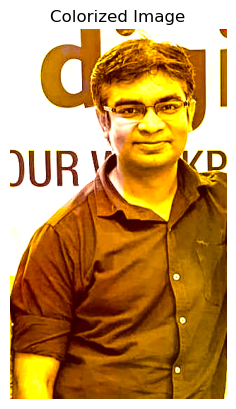

In [31]:
# Visualize
sample_path = '/home/mmanani/ImageColourizationDataSet/sourceimages/Wild-Horse-Wyoming-3284-Edit-Edit-BW.jpg'
sample_path2 = '/home/mmanani/ImageColourizationDataSet/sourceimages/Grayscaleimage43180.jpg'
colorized_img = colorize_image(sample_path, G)
colorized_img2 = colorize_image(sample_path2, G)
plt.imshow(colorized_img)
plt.imshow(colorized_img2)
plt.title("Colorized Image")
plt.axis('off')
plt.show()



In [ ]:
#######################################################################
############# JUST A BACKUP NOT FOR RUNNIG ############################
#######################################################################

# Initialize CSV file (Cell 4 ya 6 ke shuru mein)
csv_file = 'training_metrics.csv'
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Epoch', 'Batch', 'G_Loss', 'D_Loss', 'PSNR', 'SSIM'])        
print("Starting GAN Training...")
models = {'G': G, 'D': D}
optimizers = {'G': optimizer_G, 'D': optimizer_D}
start_epoch, start_batch = load_checkpoint(os.path.join(checkpoint_dir, 'gan_checkpoint.pth'), models, optimizers)
if start_epoch > 0:
    start_epoch += 1   # ← YEHI MISSING THI!
    print(f"Resuming training from Epoch {start_epoch}")# Load pretrain weights for G if GAN fresh
if start_epoch == 0:
    g_checkpoint = torch.load(os.path.join(checkpoint_dir, 'pretrain_checkpoint.pth'))
    G.load_state_dict(g_checkpoint['model_state_dict'])
    print("Loaded pretrain weights for G")
    for epoch in range(start_epoch, num_epochs):
    total_g_loss, total_d_loss = 0, 0
    metrics_list = []  # Store metrics per epoch
    start_time = time.time()
    if epoch == start_epoch and start_batch > 0:
        iterator = iter(train_loader)
        for _ in range(start_batch):
            next(iterator)
        batches = iterator
    else:
        batches = train_loader
    for batch_idx, batch in enumerate(tqdm(batches, desc=f"GAN Epoch {epoch+1}/{num_epochs}", total=len(train_loader))):
    if epoch == start_epoch and batch_idx < start_batch:
        continue
    L = batch['L'].to(device)
    real_ab = batch['ab'].to(device)
    L = L.detach()
    real_ab = real_ab.detach()
    g_loss, d_loss = train_step(G, D, optimizer_G, optimizer_D, real_ab, L)
    # Metrics calculation (if ground truth available)
    psnr_score = None
    ssim_score = None
    if real_ab is not None:
        fake_ab = G(L)
        fake_ab = fake_ab.detach()  # ← ADD YE LINE
        fake_rgb = torch.cat((L, fake_ab), dim=1).detach()
        real_rgb = torch.cat((L, real_ab), dim=1).detach()
        fake_rgb = fake_rgb.cpu().numpy().transpose(0, 2, 3, 1) * 255
        real_rgb = real_rgb.cpu().numpy().transpose(0, 2, 3, 1) * 255
        psnr_score = psnr(real_rgb[0], fake_rgb[0], data_range=255)
        # Replace SSIM line
        if real_rgb.shape[0] >= 3 and real_rgb.shape[1] >= 3:
            ssim_score = ssim(real_rgb[0], fake_rgb[0], multichannel=True, data_range=255, win_size=3)
        else:
            ssim_score = 0.0
        # Check if g_loss and d_loss are tensors before .item()
        g_loss_val = g_loss.item() if torch.is_tensor(g_loss) else g_loss
        d_loss_val = d_loss.item() if torch.is_tensor(d_loss) else d_loss
        metrics_list.append([epoch, batch_idx, g_loss_val, d_loss_val, psnr_score, ssim_score])
    
    total_g_loss += g_loss.item() if torch.is_tensor(g_loss) else g_loss
    total_d_loss += d_loss.item() if torch.is_tensor(d_loss) else d_loss
    #elapsed_time = time.time() - start_time
    #if elapsed_time >= 600:
        #print(f"Pausing for 1 min at {elapsed_time:.1f}s...")
        #time.sleep(60)
        #start_time = time.time()

# Save metrics to CSV at epoch end
with open(csv_file, 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(metrics_list)

avg_g = total_g_loss / len(train_loader)
avg_d = total_d_loss / len(train_loader)
# Training loop mein har 5 epoch pe test kar
test_img = '/home/mmanani/ImageColourizationDataSet/sourceimages/Wild-Horse-Wyoming-3284-Edit-Edit-BW.jpg'
test_img2 = '/home/mmanani/ImageColourizationDataSet/sourceimages/Tips-Black-and-White-Portrait-Photography.jpg'

colorized = colorize_image(test_img, G)  # Upar wala inference function
colorized2 = colorize_image(test_img2, G)  # Upar wala inference function

plt.imsave(f"/home/mmanani/ImageColourizationDataSet/generatedcolouredimages/test_epoch_{epoch+1}.jpg", colorized)
plt.imsave(f"/home/mmanani/ImageColourizationDataSet/generatedcolouredimages/test2_epoch_{epoch+1}.jpg", colorized2)
#print(f"Test saved: test_epoch_{epoch+1}.jpg")
print(f"GAN Epoch [{epoch+1}/{num_epochs}], G Loss: {avg_g:.4f}, D Loss: {avg_d:.4f}")
G.eval()  # ← Inference ke liye zaroori!
torch.save({
    'epoch': epoch+1,
    'batch': 0,
    'model_state_dict': {'G': G.state_dict(), 'D': D.state_dict()},
    'optimizer_state_dict': {'G': optimizer_G.state_dict(), 'D': optimizer_D.state_dict()},
    'loss': {'G': avg_g, 'D': avg_d}
}, os.path.join(checkpoint_dir, 'gan_checkpoint.pth'))
save_per_epoch_copy(epoch, checkpoint_dir)torch.save(G.state_dict(), '/home/mmanani/ImageColourizationDataSet/generator_final.pth')
torch.save(D.state_dict(), '/home/mmanani/ImageColourizationDataSet/discriminator_final.pth')
print("GAN Training completed!")

Using device: cpu
✅ Generator weights loaded successfully.


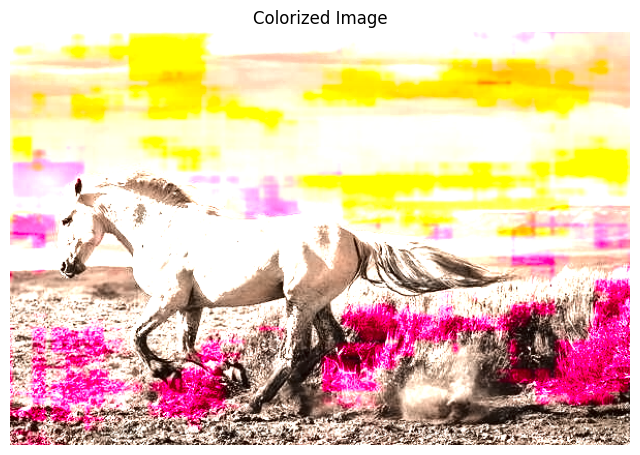

In [7]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import lab2rgb

# -------------------------------
# 1️⃣  Generator Model Definition
# -------------------------------
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 2, 4, 2, 1), nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# -------------------------------
# 2️⃣  Colorization Function
# -------------------------------
def colorize_image(image_path, G, device):
    G.eval()

    # Load and preprocess image
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image at {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Convert to LAB color space
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    l_channel = lab[:, :, 0]

    # ✅ Match training normalization (divide by 255.0)
    l_resized = cv2.resize(l_channel, (256, 256)) / 255.0

    # Convert to tensor and infer
    l_input = torch.from_numpy(l_resized).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        ab_pred = G(l_input)
        ab_pred = torch.clamp(ab_pred, -1, 1)
        ab_pred = ab_pred.squeeze(0).cpu().numpy() * 128  # [-128,127] range

    # Resize and smooth ab channels
    ab_resized = cv2.resize(ab_pred.transpose(1, 2, 0), (w, h), cv2.INTER_CUBIC)
    ab_resized = cv2.GaussianBlur(ab_resized, (5, 5), 0)

    # Combine L + ab back to LAB
    lab_full = np.dstack((l_channel, ab_resized)).astype(np.float64)

    # Convert LAB → RGB
    rgb = lab2rgb(lab_full)
    rgb_uint8 = (rgb * 255).astype(np.uint8)

    return rgb_uint8


# -------------------------------
# 3️⃣  Run Inference in Notebook
# -------------------------------
# 💾 Define paths here
checkpoint_path = "./gan_checkpoint_epoch_53.pth"
sample_image_path = "./Wild-Horse-Wyoming-3284-Edit-Edit-BW.jpg"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize and load generator weights
G = Generator().to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)

if "model_state_dict" in checkpoint and "G" in checkpoint["model_state_dict"]:
    G.load_state_dict(checkpoint["model_state_dict"]["G"])
    print("✅ Generator weights loaded successfully.")
else:
    raise KeyError("Checkpoint does not contain Generator weights under ['model_state_dict']['G'].")

# Perform inference
result = colorize_image(sample_image_path, G, device)

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(result)
plt.axis("off")
plt.title("Colorized Image")
plt.show()


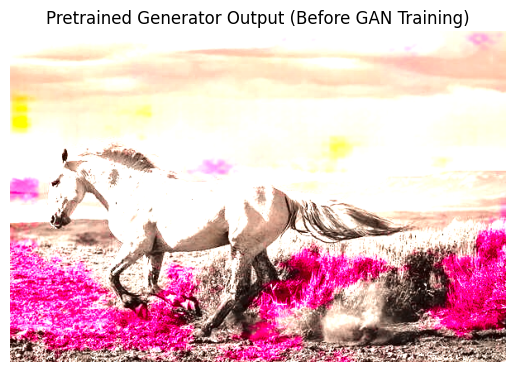

In [ ]:
import torch

# Load pretrained generator weights on CPU
checkpoint = torch.load('pretrain_checkpoint.pth', map_location=torch.device('cpu'))
G.load_state_dict(checkpoint['model_state_dict'])

# Run inference
colorized = colorize_image('./Wild-Horse-Wyoming-3284-Edit-Edit-BW.jpg', G, device='cpu')

import matplotlib.pyplot as plt
plt.imshow(colorized)
plt.title("Pretrained Generator Output (Before GAN Training)")
plt.axis('off')
plt.show()

